In [11]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

In [12]:
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader
from src.models.node_lstm import NodeLSTM

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


(<Figure size 2200x600 with 2 Axes>, <Axes: title={'center': 'node: 1'}>)

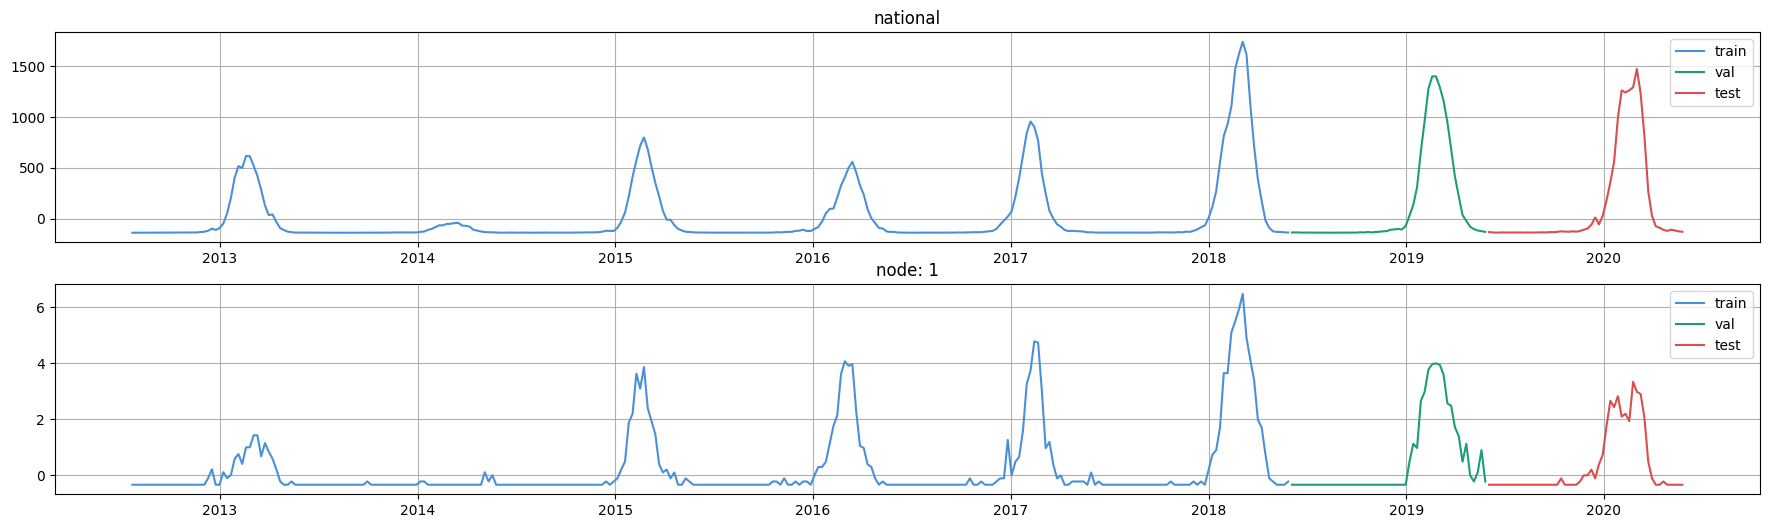

In [13]:
epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(2,8))
epidata.preview()

single snapshot: Data(x=[399, 9, 10], y=[399])
Epoch 0 train MSE: 5.6560, val MSE: 11.7684 ✓ (new best)
Epoch 1 train MSE: 5.4762, val MSE: 11.1027 ✓ (new best)
Epoch 2 train MSE: 5.0080, val MSE: 8.6052 ✓ (new best)
Epoch 3 train MSE: 3.9509, val MSE: 4.7331 ✓ (new best)
Epoch 4 train MSE: 3.6925, val MSE: 4.1899 ✓ (new best)
Epoch 5 train MSE: 3.5672, val MSE: 3.9277 ✓ (new best)
Epoch 6 train MSE: 3.4459, val MSE: 3.7339 ✓ (new best)
Epoch 7 train MSE: 3.3427, val MSE: 3.5761 ✓ (new best)
Epoch 8 train MSE: 3.2527, val MSE: 3.4424 ✓ (new best)
Epoch 9 train MSE: 3.1723, val MSE: 3.3268 ✓ (new best)
Epoch 10 train MSE: 3.0995, val MSE: 3.2255 ✓ (new best)
Epoch 11 train MSE: 3.0326, val MSE: 3.1361 ✓ (new best)
Epoch 12 train MSE: 2.9705, val MSE: 3.0566 ✓ (new best)
Epoch 13 train MSE: 2.9126, val MSE: 2.9858 ✓ (new best)
Epoch 14 train MSE: 2.8581, val MSE: 2.9221 ✓ (new best)
Epoch 15 train MSE: 2.8149, val MSE: 2.8702 ✓ (new best)
Epoch 16 train MSE: 2.7188, val MSE: 2.8151 ✓ (ne

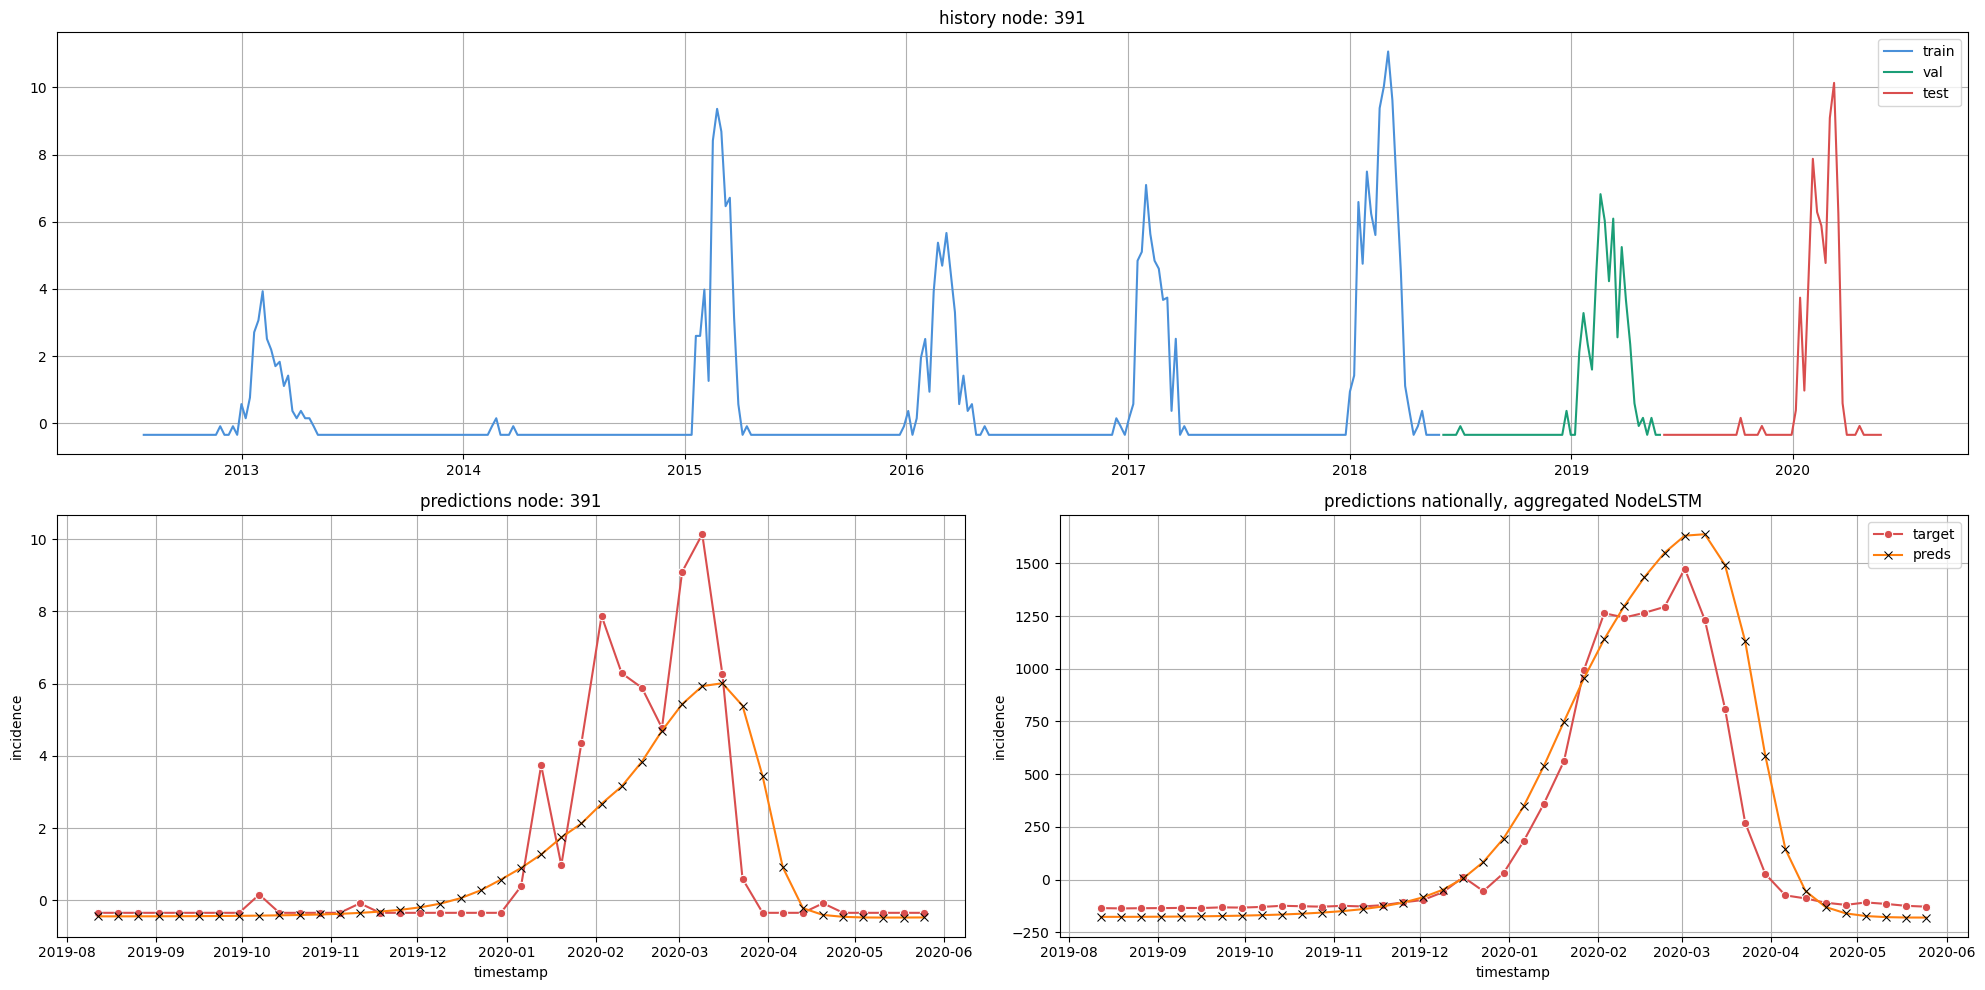

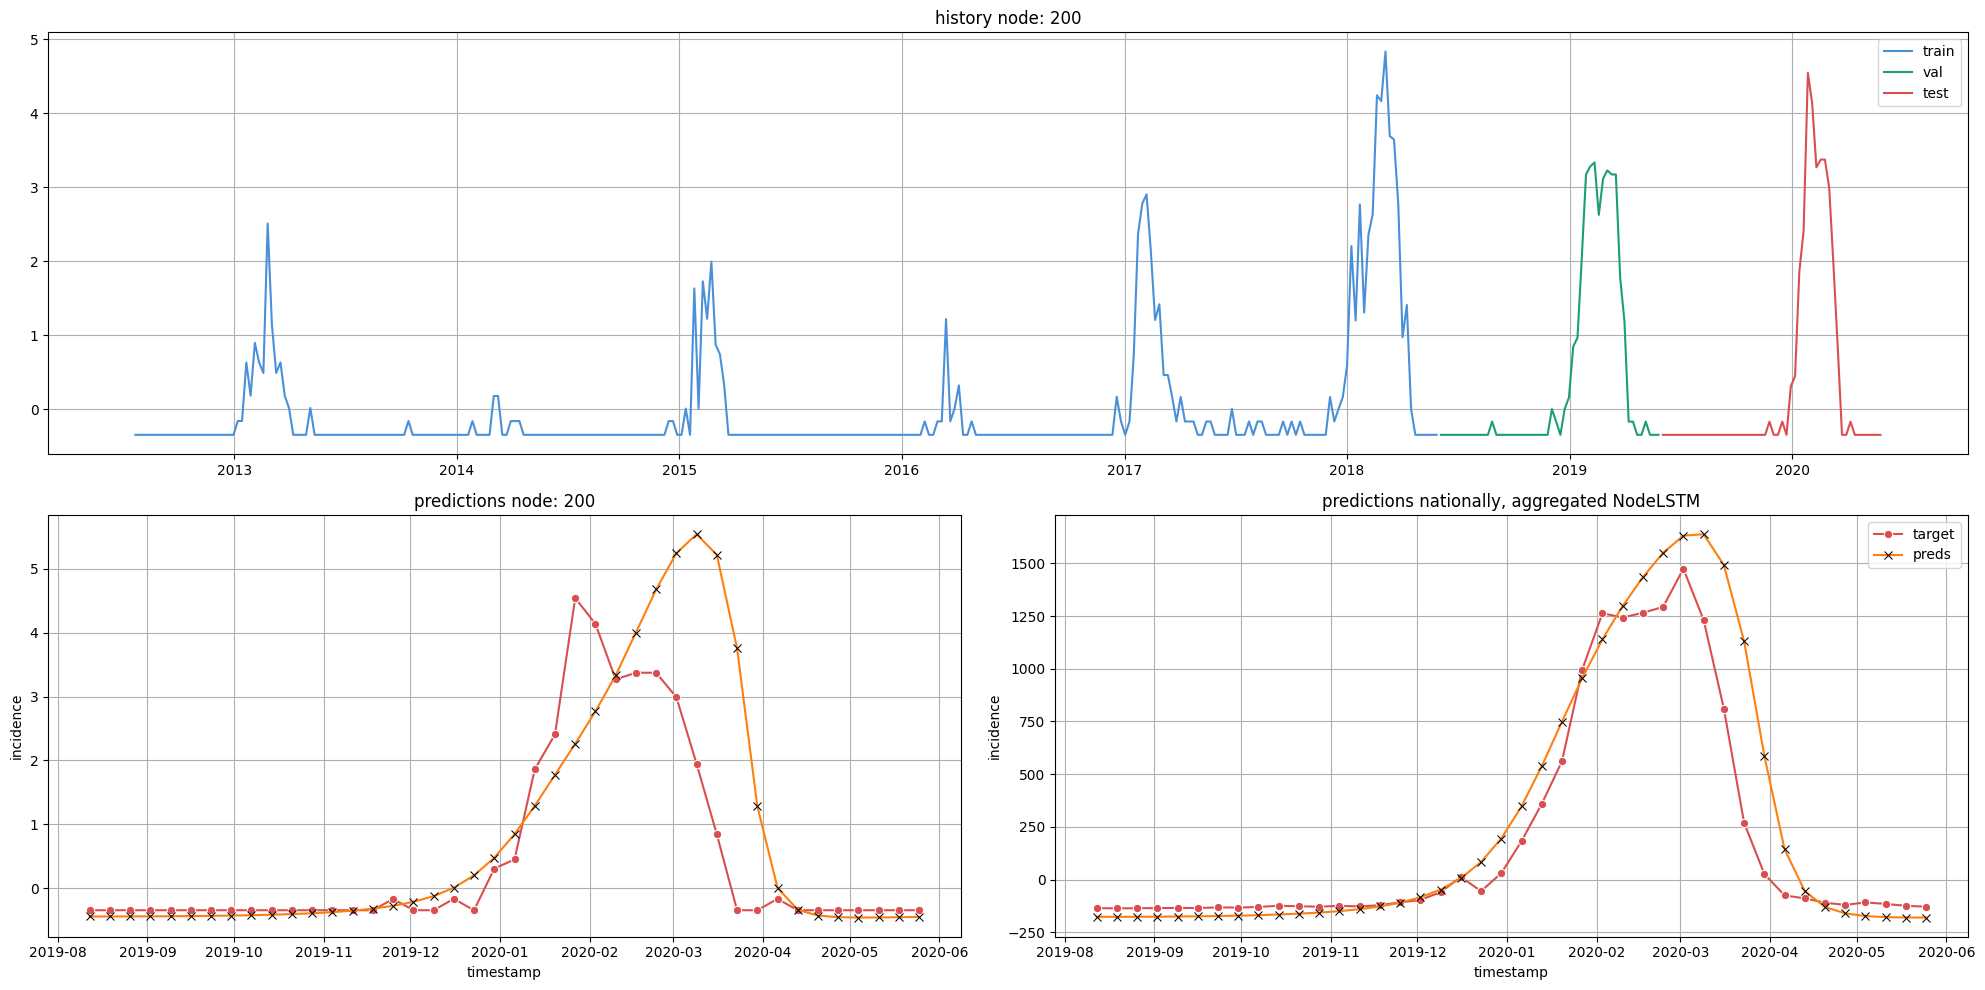

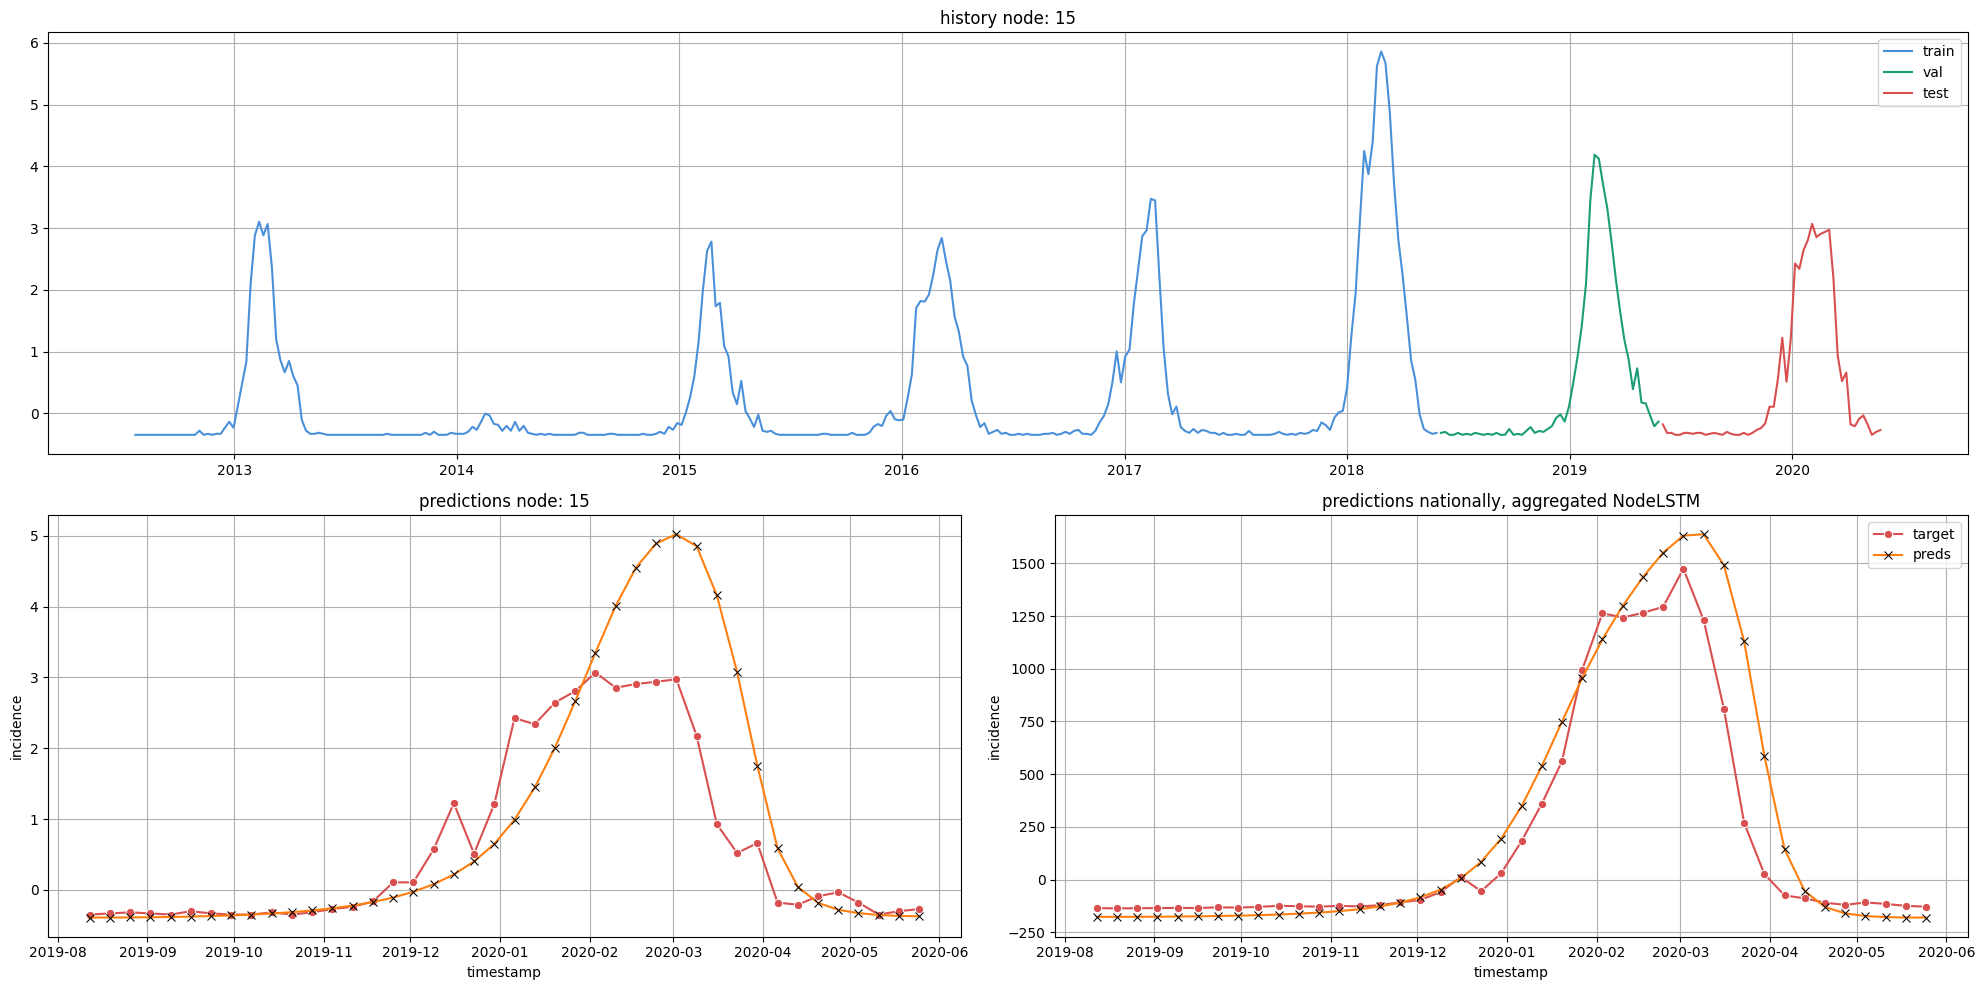

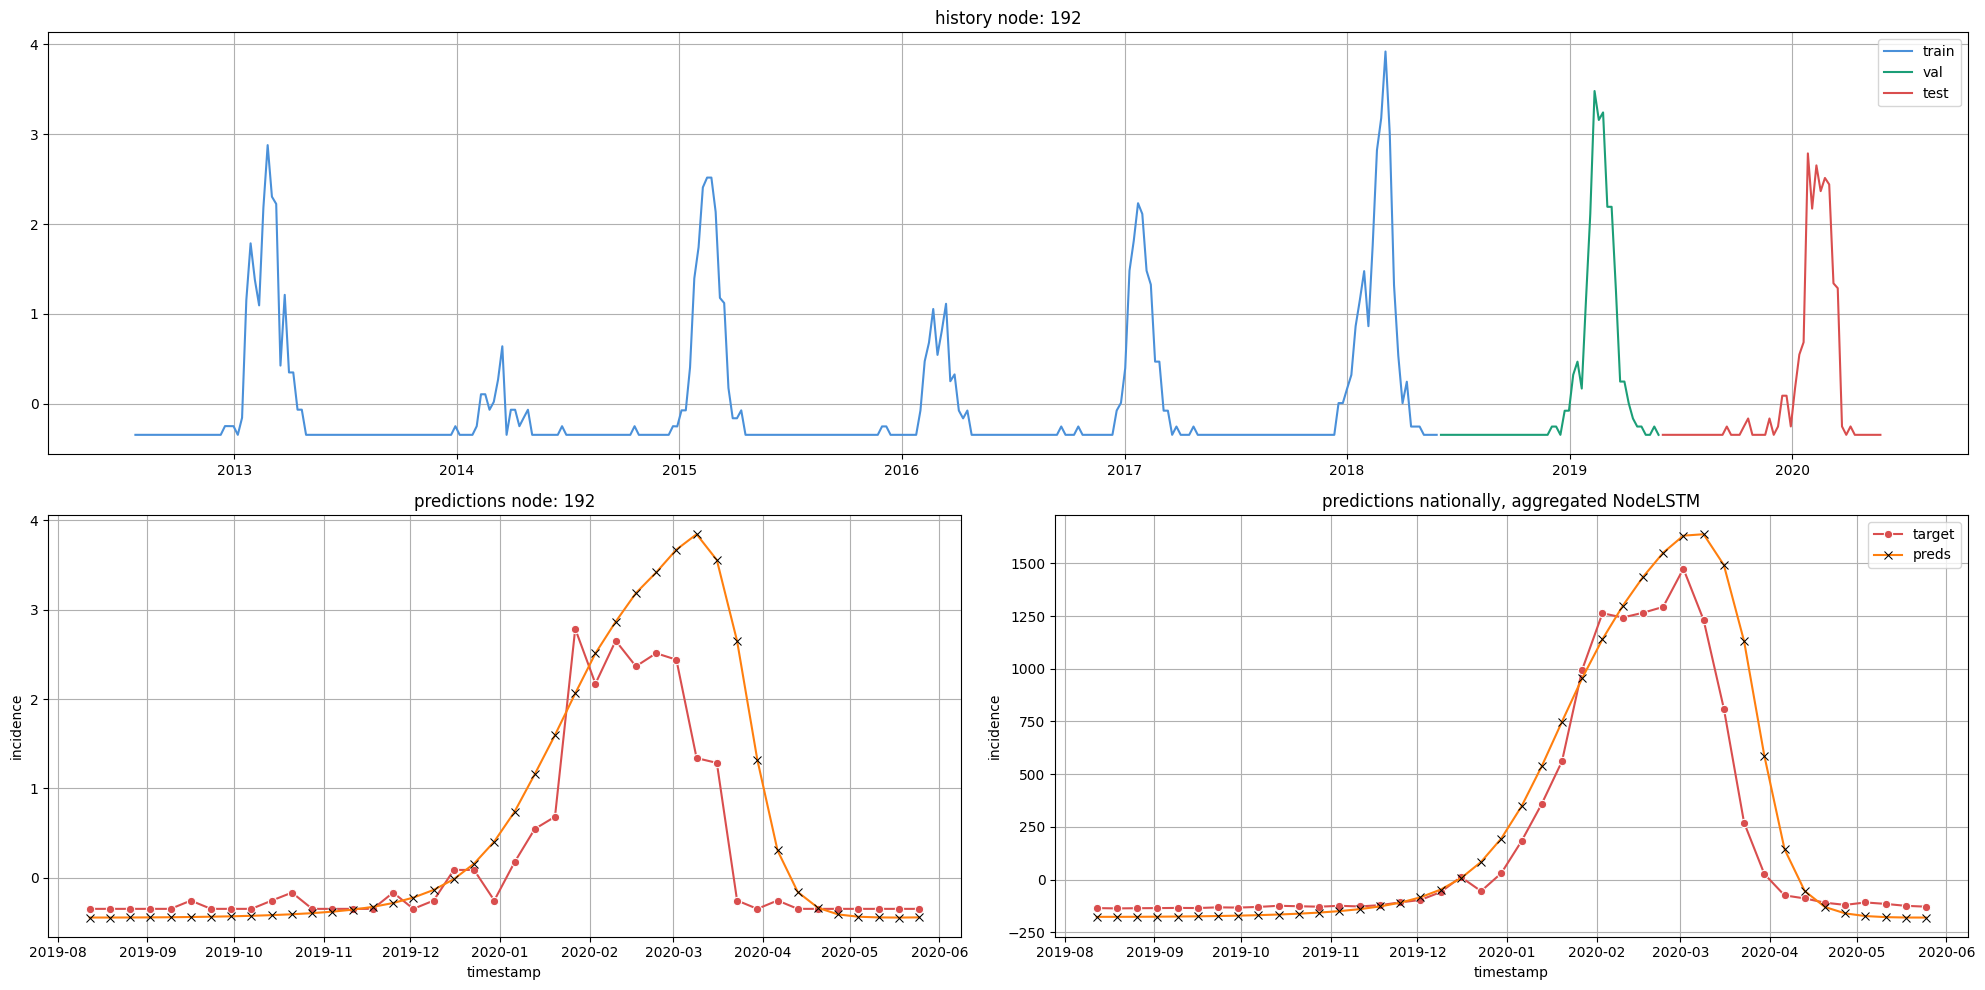

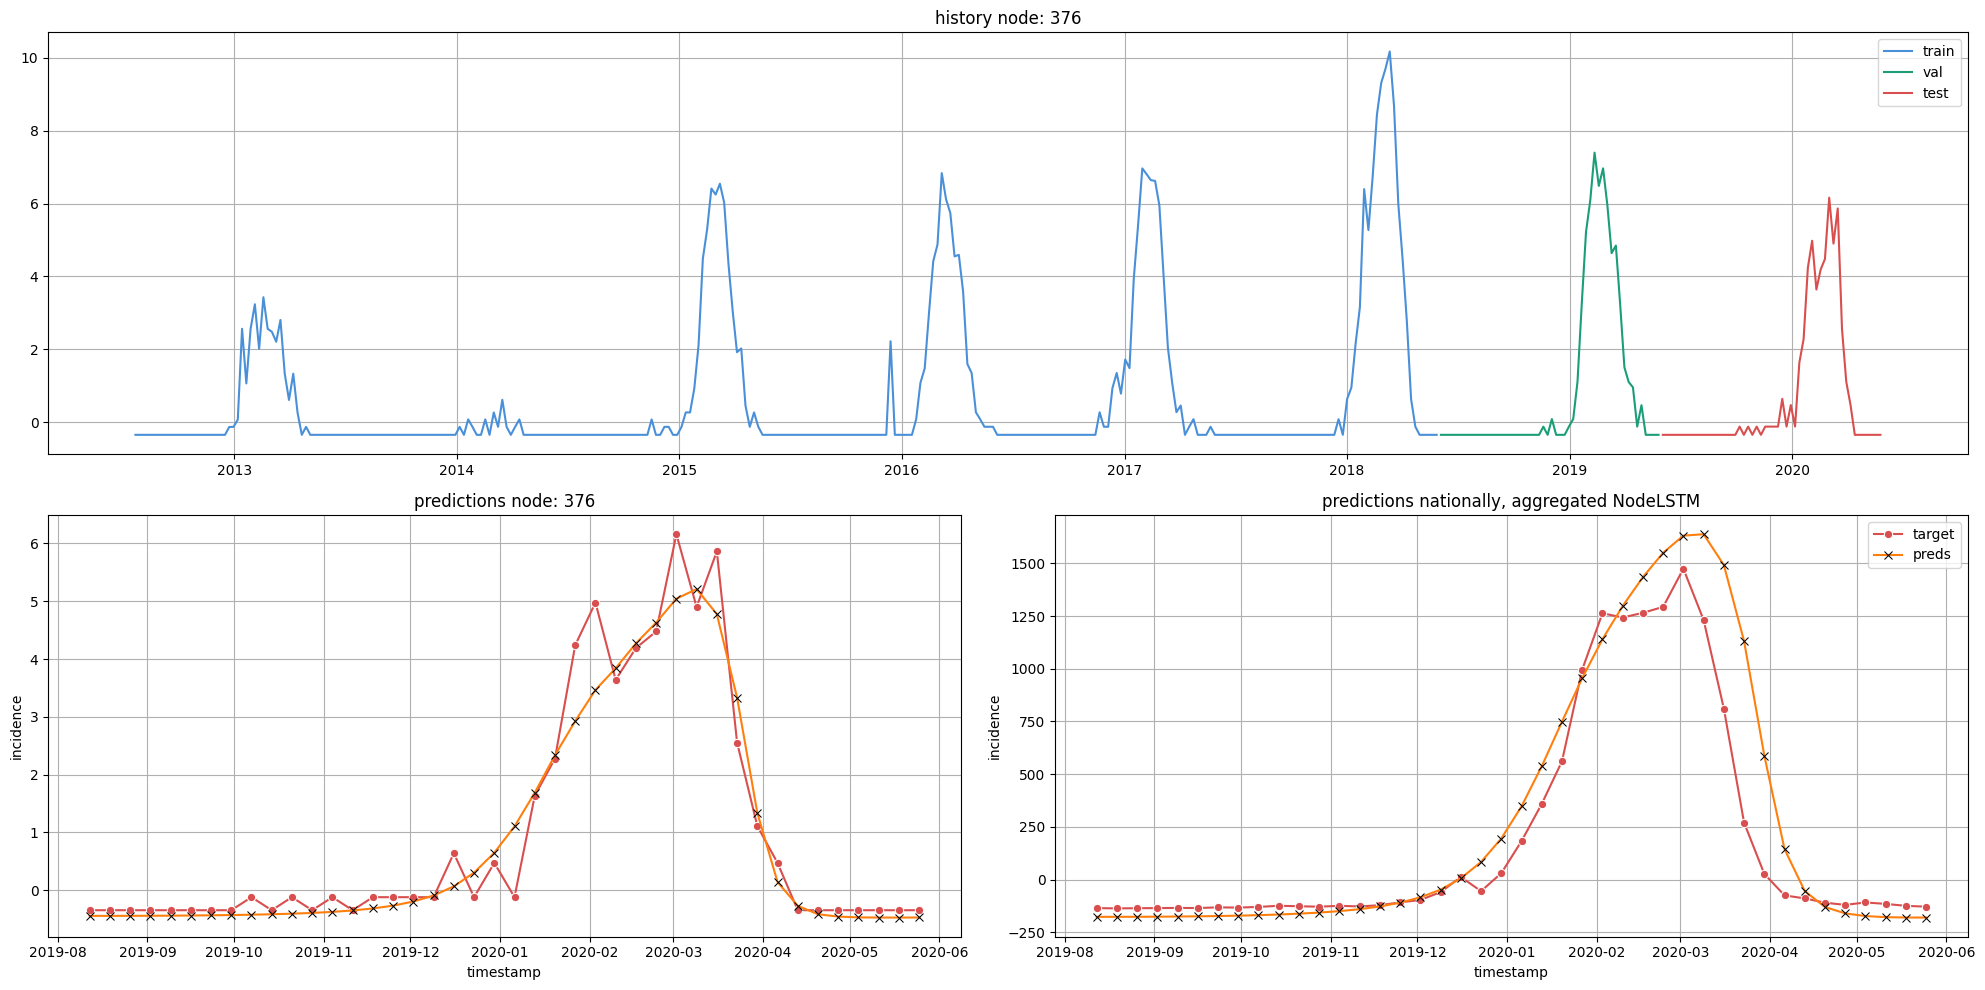

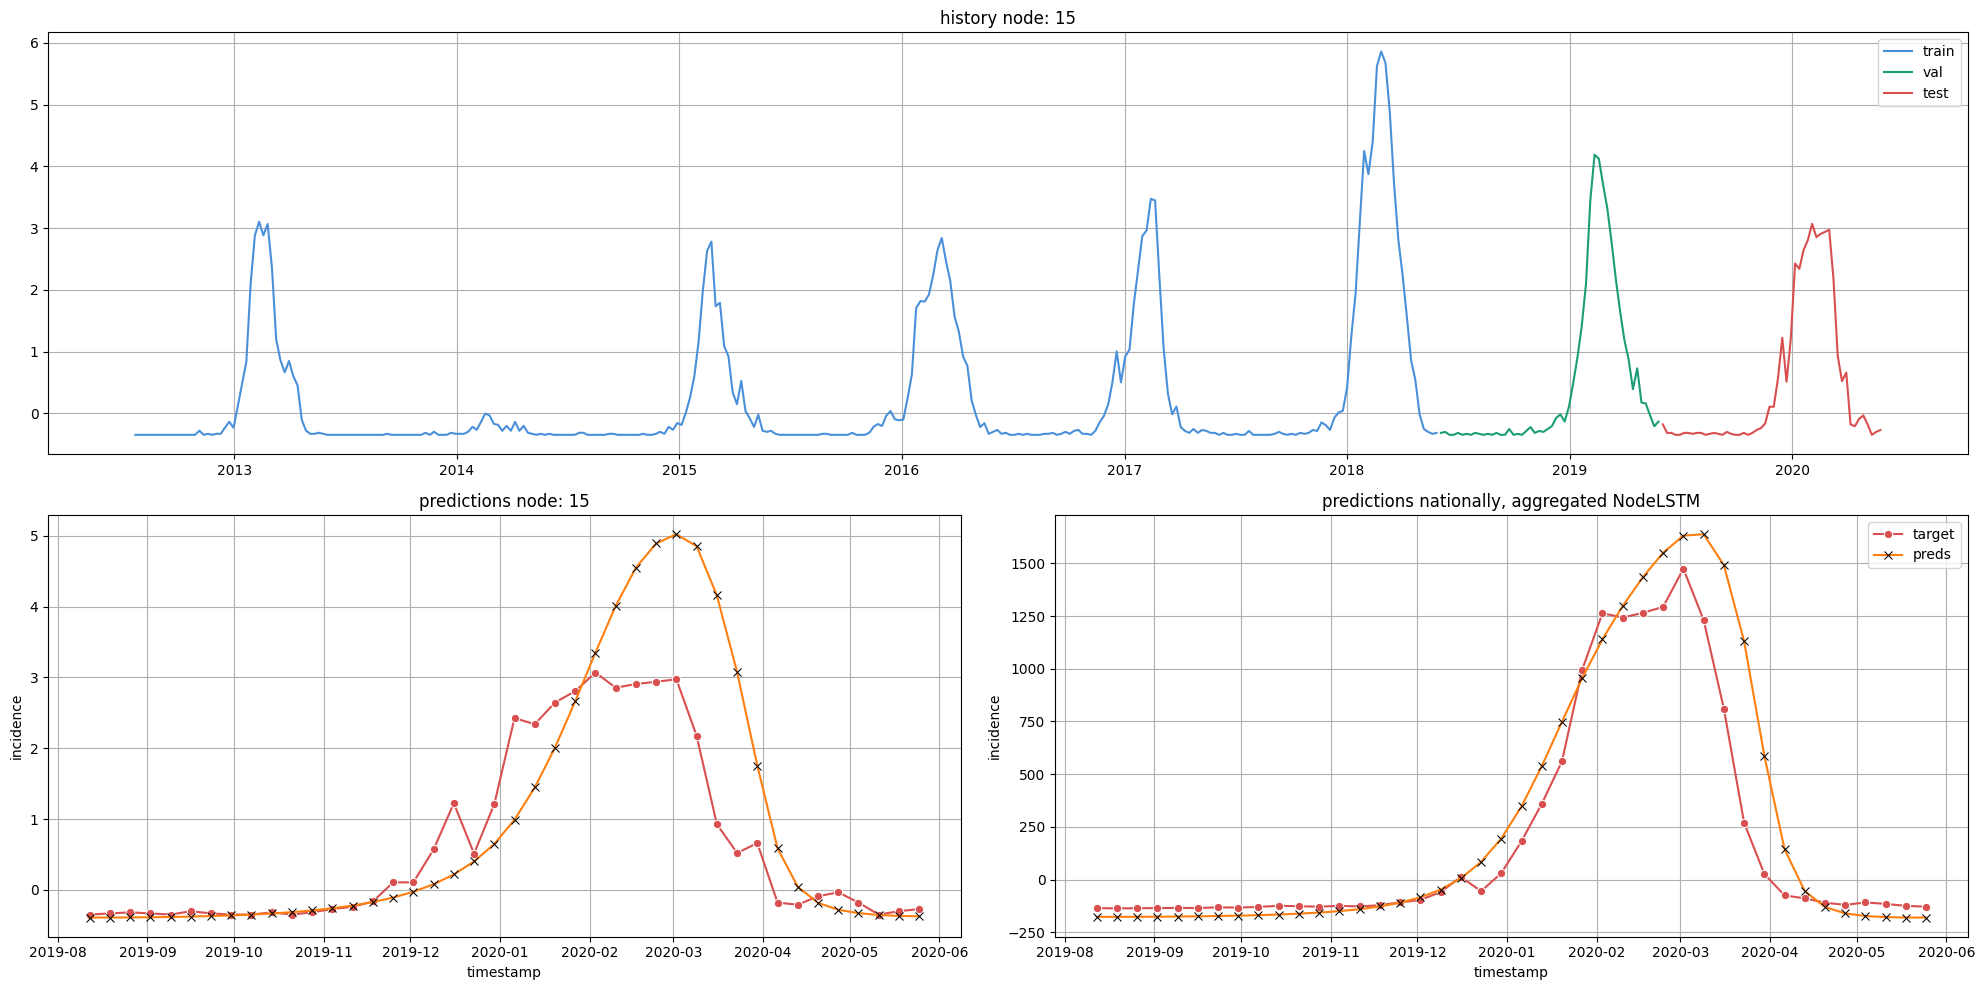

In [15]:
n_epochs = 50


dataloader_NodeLSTM = GNNDataLoader(epidata).construct_dataloaders(periods = 10)
nodelstm_model = NodeLSTM(dataloader_NodeLSTM)

nodelstm_model.set_model_hparams(hidden_size=256, num_layers = 4)

nodelstm_model.set_global_hparams(lr = 0.00001, 
                                  n_epochs = n_epochs,     
                                  optimizer='adam', 
                                  scheduler='step',
                                  scheduler_kwargs={'step_size': 15,
                                                    'gamma' : 0.8},
                                loss = 'spike_weighted_mse',
                                min_delta = 1e-4
                                  )

nodelstm_model.train()
nodelstm_model.forecast()
nodelstm_model.show_forecasts(391)
nodelstm_model.show_forecasts(200)
nodelstm_model.show_forecasts(15)

nodelstm_model.show_forecasts(192)
nodelstm_model.show_forecasts(376)
nodelstm_model.show_forecasts(15)